In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import matplotlib
import seaborn as sns
import copy
import pickle
import warnings
warnings.filterwarnings('ignore')
import shap
from models import *
from utilities import *

2025-12-01 13:42:54.485093: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-01 13:42:54.485139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-01 13:42:54.486422: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-01 13:42:54.493134: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[INFO] No GPU found, using CPU.


In [3]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
matplotlib.rc('font', family='sans-serif') 
matplotlib.rc('font', serif='Helvetica Neue') 

In [4]:
##########################################################################################################

In [5]:
import tensorflow as tf
# tf.compat.v1.disable_v2_behavior()

In [6]:
# shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough 
# shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough

In [7]:
################### data import ###############

In [8]:
data_dir = '../results/data/'
data_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_dy_filter.pkl')
ba_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_ba_filter.pkl')

In [9]:
data_copy['Id_encoded'], uniques = pd.factorize(data_copy['SCCRIP_ID'])
mapping_dict = {value: index for index, value in enumerate(uniques)}

In [10]:
ba_copy['Id_encoded'] = ba_copy['SCCRIP_ID'].map(mapping_dict)
ba_copy = ba_copy[ba_copy['Id_encoded'].notna()]
ba_copy = ba_copy.drop_duplicates(subset='SCCRIP_ID', keep='last')
ba_copy.drop('SCCRIP_ID', inplace=True, axis=1)

In [11]:
ba_copy = ba_copy.fillna(0)
data_copy = data_copy.fillna(0)

In [13]:
len(data_copy.SCCRIP_ID.unique())

1267

In [14]:
feature_dy = data_copy.drop(['HU_status','Id_encoded','SCCRIP_ID'],axis=1).columns
feature_ba = ba_copy.drop(['Id_encoded'], axis=1).columns

In [15]:
################ data process ##################

In [16]:
seq_length = 5

In [17]:
sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)

In [18]:
(X_train,X_val,X_test,
            X_bg_train,X_bg_val,X_bg_test,
            dt_train, dt_val, dt_test, 
            y_train,y_val,y_test,
            ls_train, ls_val, ls_test,
            seq_map_train, seq_map_val, seq_map_test) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)


In [19]:
X_train.shape, X_bg_train.shape, dt_train.shape

((17815, 5, 786), (17815, 1, 23), (17815, 1, 1))

In [150]:
# Initialize the model class
combined_model = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train.shape[2]), bg_features=int(X_bg_train.shape[2]))

Model input shapes: (None, 5, 786) (None, 1, 23) (None, 1, 1)
Model: "CombinedLSTMModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_bg (InputLayer)       [(None, 1, 23)]              0         []                            
                                                                                                  
 input_dt (InputLayer)       [(None, 1, 1)]               0         []                            
                                                                                                  
 input_seq (InputLayer)      [(None, 5, 786)]             0         []                            
                                                                                                  
 bg_plus_dt (Concatenate)    (None, 1, 24)                0         ['input_bg[0][0]',            
                    

In [151]:
# Train the model
history = combined_model.train(
    X_train, X_bg_train, dt_train, y_train,
    X_val,   X_bg_val,   dt_val,   y_val,
    epochs=20, batch_size=64,
    checkpoint_path="../results/models/mix_best2.h5"
)

Epoch 1/20
282/285 [============================>.] - ETA: 0s - loss: 117.3280 - mean_absolute_error: 7.1598
Epoch 1: val_loss improved from inf to 31.86095, saving model to ../results/models/mix_best2.h5
285/285 [==============================] - 3s 7ms/step - loss: 116.5391 - mean_absolute_error: 7.1243 - val_loss: 31.8609 - val_mean_absolute_error: 3.6365
Epoch 2/20
283/285 [============================>.] - ETA: 0s - loss: 15.1367 - mean_absolute_error: 2.6213
Epoch 2: val_loss improved from 31.86095 to 19.06337, saving model to ../results/models/mix_best2.h5
285/285 [==============================] - 2s 5ms/step - loss: 15.1262 - mean_absolute_error: 2.6210 - val_loss: 19.0634 - val_mean_absolute_error: 2.9575
Epoch 3/20
276/285 [============================>.] - ETA: 0s - loss: 21.8936 - mean_absolute_error: 2.9563
Epoch 3: val_loss improved from 19.06337 to 16.69885, saving model to ../results/models/mix_best2.h5
285/285 [==============================] - 2s 5ms/step - loss: 21.

In [152]:
# Load the model
combined_model.save("../results/models/mix_best2.h5")
combined_model.load("../results/models/mix_best2.h5")

In [153]:
# Make predictions on the test set
y_pred = combined_model.predict(X_test, X_bg_test, dt_test)

197/197 [==============================] - 1s 2ms/step


In [154]:
figure_dir = '../results/figures/mix/'
ensure_directory_exists(figure_dir)

Directory '../results/figures/mix/' already exists.


In [155]:
def mae_np(y_pred, y_true):
    return np.mean(np.abs(y_pred - y_true))

def rmse_np(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true)**2))

Mean Squared Error: 9.6372
Mean Absolute Error: 2.0839
R^2 Score: 0.9065
r: 0.9522
mae: 2.0839
rmse: 3.1044


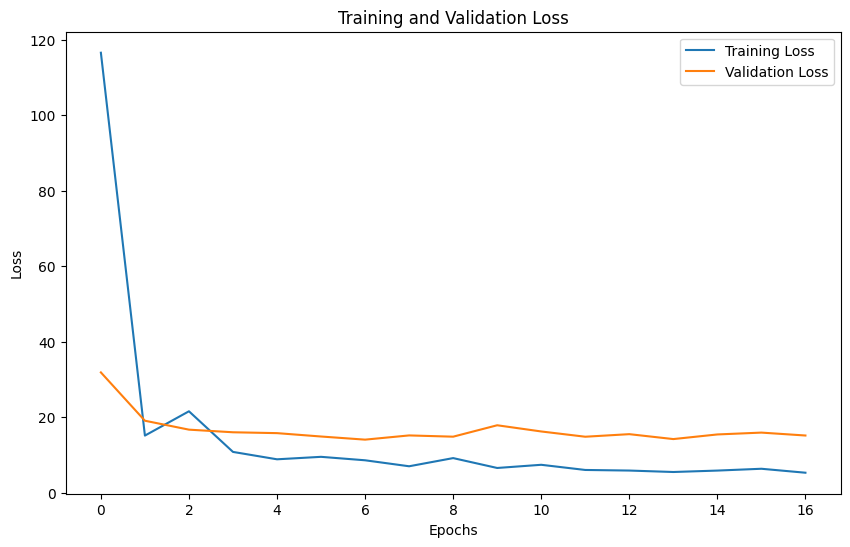

In [156]:
from scipy.stats import pearsonr
mse = mean_squared_error(y_test.flatten(), y_pred.flatten())
mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
r2 = r2_score(y_test.flatten(), y_pred.flatten())
r, _  = pearsonr(y_test.flatten(), y_pred.flatten())
mae = mae_np(y_test.flatten(), y_pred.flatten())
rmse = rmse_np(y_test.flatten(), y_pred.flatten())

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"r: {r:.4f}")
print(f"mae: {mae:.4f}")
print(f"rmse: {rmse:.4f}")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# plt.savefig(figure_dir + 'LOSS.pdf')
plt.show()

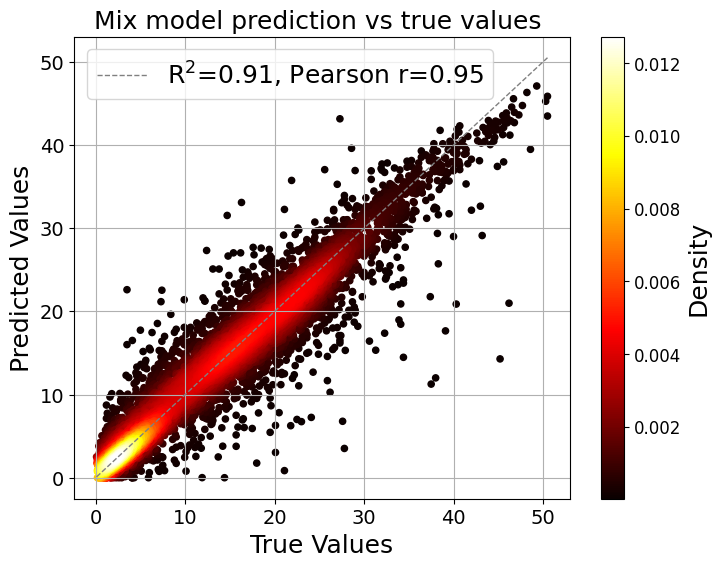

In [159]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_grey", ["#B3B3B3", "#4D4D4D"])

from scipy.stats import gaussian_kde, linregress

y_test = y_test.reshape(y_test.shape[0])
y_pred = y_pred.reshape(y_pred.shape[0])
xy = np.vstack([y_test, y_pred])
xy = np.nan_to_num(xy)
z = gaussian_kde(xy)(xy)

# Sort the points by density (optional, for better visualization)
idx = z.argsort()
y_test, y_pred, z = y_test[idx], y_pred[idx], z[idx]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    y_test,
    y_pred,
    c=z,
    cmap='hot',   # or 'plasma', 'inferno', etc.
    s=20,
    edgecolor=None
)

x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, x_line, linestyle='dashed', color='grey', linewidth=1,  label=f'R$^2$={r2:.2f}, Pearson r={r:.2f}')
plt.xlabel('True Values', fontsize=18)
plt.ylabel('Predicted Values',fontsize=18)
# plt.xlim([0,80])
# plt.ylim([0,80])
cbar = fig.colorbar(sc)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Density', fontsize=18)
ax.tick_params(labelsize=14)

plt.title('Mix model prediction vs true values ', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True)
plt.savefig(figure_dir+'dot_dot2.pdf')

In [ ]:
###############################################

In [167]:
# Split predictions and true values
import random
y_test_split = split_predictions_to_series(sequences_copy, seq_map_test, y_test, seq_length)
y_pred_split = split_predictions_to_series(sequences_copy, seq_map_test, y_pred, seq_length)

i_list = []
for i, l in enumerate(y_test_split):
    if len(l) >= 100:
        i_list.append(i)
v = random.choice(i_list)
# Example: Access the first time series predictions and true values
y_test_series_0 = y_test_split[v]
y_pred_series_0 = y_pred_split[v]

# Print shapes for verification
print(f"Original test series 0 shape: {y_test_series_0.shape}")
print(f"Predicted series 0 shape: {y_pred_series_0.shape}")


Original test series 0 shape: (100,)
Predicted series 0 shape: (100,)


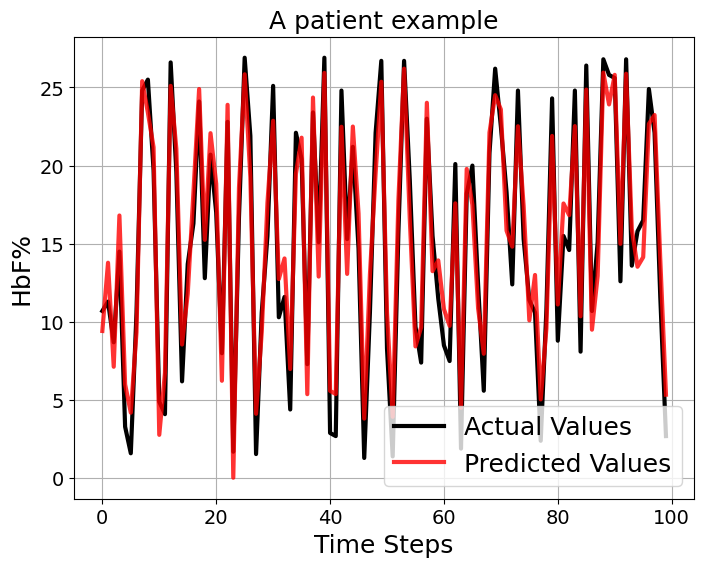

In [169]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(y_test_series_0.flatten(),lw=3, label='Actual Values', color='k')
plt.plot(y_pred_series_0.flatten(), lw=3, label='Predicted Values', color='red', alpha=0.8)
plt.title('A patient example', fontsize=18)
plt.xlabel('Time Steps', fontsize=18)
plt.ylabel('HbF%', fontsize=18)
ax.tick_params(labelsize=14)
plt.legend(fontsize=18)
plt.grid()
plt.savefig(figure_dir + 'example2.pdf')
plt.show()


In [ ]:
######################## loop for r-square and shap

In [ ]:
r2 = []
shap_impact = []
sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)
while len(shap_impact) < 20:

    (X_train,X_val,X_test,
                X_bg_train,X_bg_val,X_bg_test,
                dt_train, dt_val, dt_test, 
                y_train,y_val,y_test,
                ls_train, ls_val, ls_test,
                seq_map_train, seq_map_val, seq_map_test) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)
    
    combined_model_l = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train.shape[2]), bg_features=int(X_bg_train.shape[2]), summary=False)
    
    history = combined_model_l.train(
    X_train, X_bg_train, dt_train, y_train,
    X_val,   X_bg_val,   dt_val,   y_val,
    epochs=20, batch_size=64,
    checkpoint_path="../results/models/Mix_best2_loop.h5")
    y_pred = combined_model_l.predict(X_test, X_bg_test, dt_test)
    r2 = r2_score(y_test.flatten(), y_pred.flatten())
    if r2 > 0:
        r2.append(r2)

        explainer = shap.GradientExplainer(combined_model_l.model, [X_test, X_bg_test, dt_test])
        shap_values = explainer.shap_values([X_test, X_bg_test, dt_test])

        shap_val_d = []
        train_d = []

        for i in range (5):
            shap_val_d.append(pd.DataFrame(shap_values[0][:,i,:,0], columns=feature_dy))
            train_d.append(pd.DataFrame(X_test[:,i,:],columns=feature_dy))
            
        shap_val_b = pd.DataFrame(shap_values[1][:,0,:,0], columns=feature_ba)
        train_b = pd.DataFrame(X_bg_test[:,0,:], columns=feature_ba)

        impact_dy = []

        for i in range(5):
            im = ABS_SHAP(shap_val_d[i], train_d[i])
            impact_dy.append(im)
            
        impact_ba = ABS_SHAP(shap_val_b, train_b)

        shap_impact.append((impact_dy, impact_ba))

In [ ]:
with open('../results/data/mix/r2_mix.pkl','wb') as f:
    pickle.dump(r2,f)

In [ ]:
with open('../results/data/mix/shap_impact_list.pkl','wb') as f:
    pickle.dump(shap_impact,f)

In [180]:
########################################## Shap Below

In [82]:
# combined_model.load("../results/models/mix_best2.h5")

In [85]:
# explainer = shap.DeepExplainer(combined_model.model, [X_test, X_bg_test, dt_test])
# shap_values = explainer.shap_values([X_test, X_bg_test, dt_test])

In [86]:
# with open('../results/data/mix/shap_values.pkl', 'wb') as f:
#     pickle.dump(shap_values, f)

In [87]:
# shap_val_d = []
# train_d = []

# for i in range (5):
#     shap_val_d.append(pd.DataFrame(shap_values[0][:,i,:,0], columns=feature_dy))
#     train_d.append(pd.DataFrame(X_test[:,i,:],columns=feature_dy))
    
# shap_val_b = pd.DataFrame(shap_values[1][:,0,:,0], columns=feature_ba)
# train_b = pd.DataFrame(X_bg_test[:,0,:], columns=feature_ba)

In [88]:
# impact_dy = []

# for i in range(5):
#     im = ABS_SHAP(shap_val_d[i], train_d[i])
#     impact_dy.append(im)
    
# impact_ba = ABS_SHAP(shap_val_b, train_b)

In [89]:
# with open('../results/data/mix/shap_impact.pkl', 'wb') as f:
#     pickle.dump((impact_dy,impact_ba), f)